Sample data:
                timestamp         price
0 2025-04-29 03:04:53.530  94634.347753
1 2025-04-29 04:04:55.231  94711.855826
2 2025-04-29 05:04:53.801  94402.847589
3 2025-04-29 06:05:22.025  94309.341506
4 2025-04-29 07:04:52.243  94736.903997

Data saved to: data/raw/bitcoin_prices.csv


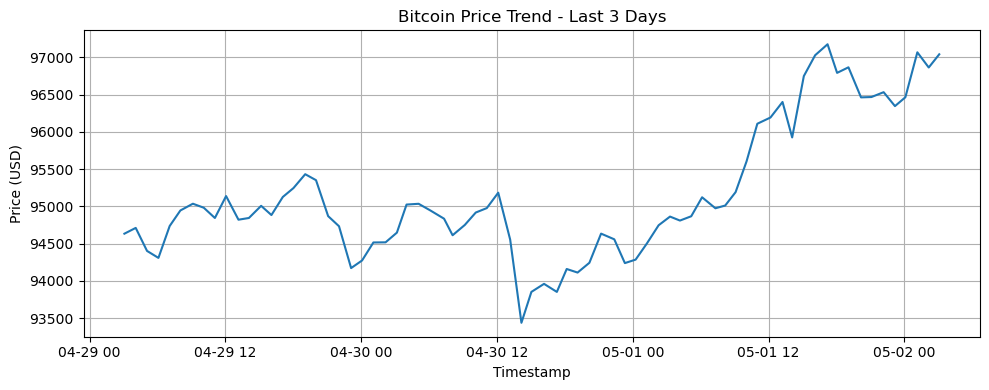

In [4]:
# Install required libraries
!pip install -q requests pandas matplotlib

# Imports
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Create directory structure
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(exist_ok=True)

# Utility function
def fetch_bitcoin_data(vs_currency="usd", days=3):
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    params = {
        "vs_currency": vs_currency,
        "days": days
    }
    response = requests.get(url, params=params, headers=headers)

    if response.status_code == 200:
        data = response.json()
        prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
        prices["timestamp"] = pd.to_datetime(prices["timestamp"], unit="ms")
        return prices
    else:
        print("Response content:", response.text)
        raise Exception(f"API Error: {response.status_code}")

# Fetch data
df = fetch_bitcoin_data(days=3)
print("Sample data:")
print(df.head())

# Save to CSV
csv_path = "data/raw/bitcoin_prices.csv"
df.to_csv(csv_path, index=False)
print(f"\nData saved to: {csv_path}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["price"])
plt.title("Bitcoin Price Trend - Last 3 Days")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/bitcoin_price_plot.png")
plt.show()


In [18]:
import os

# Define directory structure
dirs = [
    "../data/raw",
    "../data/processed",
    "../notebooks",
    "../scripts",
    "../models",
    "../reports/figures"
]

# Create all directories
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Project structure created!")


Project structure created!


In [20]:
import os
import requests
import pandas as pd
from datetime import datetime


In [22]:
# CoinDesk API endpoint
url = "https://api.coindesk.com/v1/bpi/currentprice.json"

# Make API request
response = requests.get(url)

# Check if request was successful
if response.status_code == 200:
    data = response.json()
    print("Data fetched successfully!")
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")


ConnectionError: HTTPSConnectionPool(host='api.coindesk.com', port=443): Max retries exceeded with url: /v1/bpi/currentprice.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x13657d220>: Failed to resolve 'api.coindesk.com' ([Errno 8] nodename nor servname provided, or not known)"))